## 08 - Wrap‑up: Findings, Limitations, and Mitigations

This notebook **summarizes the key results** from Notebooks **01–07** and turns them into:
- a coherent set of **final conclusions** about *bias, under‑representation, and (short‑term) reinforcement*;
- a **requirements checklist** (what is already covered vs. what is missing);
- a short, justified set of **mitigation ideas** that can be described in my report.

### Setup and Data Loading

Files from previous notebooks and Imports necessary

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

def find_processed_dir():
    here = Path.cwd().resolve()
    for base in [here, *here.parents]:
        p = base / "data" / "processed"
        if p.exists():
            return p
    raise FileNotFoundError("Could not find data/processed by walking up from the current working directory.")

PROCESSED = find_processed_dir()
print("Using PROCESSED =", PROCESSED)


def standardize_clicks(df: pd.DataFrame) -> pd.DataFrame:
    cols = set(df.columns)

    imp_col = "impression_id" if "impression_id" in cols else ("imp_id" if "imp_id" in cols else None)
    uid_col = "user_id" if "user_id" in cols else ("uid" if "uid" in cols else None)
    nid_col = "news_id" if "news_id" in cols else ("nid" if "nid" in cols else None)
    clk_col = "clicked" if "clicked" in cols else ("click" if "click" in cols else None)

    assert imp_col and uid_col and nid_col and clk_col, f"Missing expected columns in: {df.columns}"

    out = df[[imp_col, uid_col, nid_col, clk_col]].copy()
    out.columns = ["impression_id", "user_id", "news_id", "clicked"]
    return out


clicks_train = pd.read_pickle(PROCESSED / "clicks_train.pkl")
clicks_dev   = pd.read_pickle(PROCESSED / "clicks_dev.pkl")
news_train   = pd.read_pickle(PROCESSED / "news_train.pkl")
news_dev     = pd.read_pickle(PROCESSED / "news_dev.pkl")

clicks_train = standardize_clicks(clicks_train)
clicks_dev   = standardize_clicks(clicks_dev)

print("clicks_train:", clicks_train.shape, " | clicks_dev:", clicks_dev.shape)
print("news_train :", news_train.shape,  " | news_dev  :", news_dev.shape)

pol_train_path = PROCESSED / "political_ideology_train.pkl"
pol_dev_path   = PROCESSED / "political_ideology_dev.pkl"
pol_train = pd.read_pickle(pol_train_path) if pol_train_path.exists() else None
pol_dev   = pd.read_pickle(pol_dev_path)   if pol_dev_path.exists()   else None
print("Loaded pol_train:", pol_train is not None, "| pol_dev:", pol_dev is not None)


Using PROCESSED = C:\Users\jlsmp\Documents\universidade\M.IA\IAS\project\data\processed
clicks_train: (5843444, 4)  | clicks_dev: (2740998, 4)
news_train : (51282, 8)  | news_dev  : (42416, 8)
Loaded pol_train: True | pol_dev: True


### Rebuild the DEV “impressions” table

Reconstruct, per **DEV impression**:
- the **candidate slate** (all shown candidates),
- the **clicked items** (ground truth for evaluation),
- the **user id**.

This lets us compute exposure statistics **on the full slate** and, when useful, on **Top‑K** after applying a scoring function.

In [2]:
impression_candidates = clicks_dev.groupby("impression_id")["news_id"].apply(list)
imp_user = clicks_dev.groupby("impression_id")["user_id"].first()

clicked_by_imp = clicks_dev.loc[clicks_dev["clicked"] == 1].groupby("impression_id")["news_id"].apply(list)
clicked_by_imp = clicked_by_imp.reindex(impression_candidates.index, fill_value=[])

print("DEV impressions:", len(impression_candidates))
print("Mean #candidates:", np.mean([len(x) for x in impression_candidates.values]).round(2))
print("Share with ≥1 click:", np.mean([len(x) > 0 for x in clicked_by_imp.values]).round(4))


DEV impressions: 73152
Mean #candidates: 37.47
Share with ≥1 click: 1.0


### Define “politics” and “engaged users” (from TRAIN)
As done in previous notebooks

In [3]:
news_train["is_politics"] = news_train["subcategory"].astype(str).str.contains("polit", case=False, na=False)
news_dev["is_politics"]   = news_dev["subcategory"].astype(str).str.contains("polit", case=False, na=False)

polit_ids_train = set(news_train.loc[news_train["is_politics"], "news_id"])
polit_ids_dev   = set(news_dev.loc[news_dev["is_politics"],   "news_id"])

# Engaged users: >= 3 TRAIN political clicks
train_pol_clicks = clicks_train.loc[(clicks_train["clicked"] == 1) & (clicks_train["news_id"].isin(polit_ids_train))]
pol_clicks_per_user = train_pol_clicks.groupby("user_id").size()

ENGAGED_THRESHOLD = 3
engaged_users = set(pol_clicks_per_user[pol_clicks_per_user >= ENGAGED_THRESHOLD].index)

print("TRAIN users:", clicks_train["user_id"].nunique())
print("DEV users  :", clicks_dev["user_id"].nunique())
print("Engaged users (>=3 TRAIN political clicks):", len(engaged_users))

def user_group(uid):
    return "engaged" if uid in engaged_users else "other"


TRAIN users: 50000
DEV users  : 50000
Engaged users (>=3 TRAIN political clicks): 627


### Baseline scoring functions

We keep this simple and reproducible:

- **Popularity baseline:** score = number of TRAIN clicks for the news item.
- **Category‑preference baseline:** estimate each user's preference distribution over categories from TRAIN clicks, then score(item) = pref(user, item.category).

These are enough to demonstrate *exposure imbalance* and test a mitigation.

In [4]:
pop_score = clicks_train.loc[clicks_train["clicked"] == 1].groupby("news_id").size().to_dict()

def pop_score_fn(imp_id, news_id):
    return float(pop_score.get(news_id, 0.0))

train_meta = news_train.set_index("news_id")[["category","subcategory"]]

train_clicks_only = clicks_train.loc[clicks_train["clicked"] == 1, ["user_id","news_id"]].copy()
train_clicks_only = train_clicks_only.join(train_meta, on="news_id", how="left")

user_cat_counts = (
    train_clicks_only.groupby(["user_id","category"])
    .size()
    .rename("cnt")
    .reset_index()
)

user_total = user_cat_counts.groupby("user_id")["cnt"].transform("sum")
user_cat_counts["pref"] = user_cat_counts["cnt"] / user_total

user_pref_cat = {
    uid: dict(zip(chunk["category"], chunk["pref"]))
    for uid, chunk in user_cat_counts.groupby("user_id")
}

dev_meta = news_dev.set_index("news_id")[["category","subcategory"]]

def cat_personal_score_fn(imp_id, news_id):
    uid = imp_user.get(imp_id, None)
    if uid is None or news_id not in dev_meta.index:
        return 0.0
    cat = dev_meta.loc[news_id, "category"]
    return float(user_pref_cat.get(uid, {}).get(cat, 0.0))

print("Popularity items with score:", len(pop_score))
print("Users with learned category preferences:", len(user_pref_cat))


Popularity items with score: 7713
Users with learned category preferences: 50000


### Measure the politics‑exposure gap (engaged vs other)

Let's compute, for each impression, the share of **politics** in the **Top‑K** (K=10 by default), then average within each group.

This reproduces the key observation from notebooks **04–05**: *engaged users tend to be shown more politics in Top‑K*.

In [5]:
def topk_politics_share(score_fn, k=10, max_impressions=None):
    ids = impression_candidates.index if max_impressions is None else impression_candidates.index[:max_impressions]
    rows = []
    for imp_id in ids:
        uid = imp_user[imp_id]
        cands = impression_candidates[imp_id]
        if len(cands) == 0:
            continue
        scores = np.array([score_fn(imp_id, nid) for nid in cands], dtype=float)
        order = np.argsort(-scores)[:k]
        topk = [cands[i] for i in order]
        share_pol = np.mean([nid in polit_ids_dev for nid in topk])
        rows.append((user_group(uid), share_pol))
    df = pd.DataFrame(rows, columns=["group","politics_share_topk"])
    return df.groupby("group")["politics_share_topk"].mean().sort_index(), df

K = 10
max_impressions = 20000

mean_pol_pop, pol_pop_df = topk_politics_share(pop_score_fn, k=K, max_impressions=max_impressions)
mean_pol_cat, pol_cat_df = topk_politics_share(cat_personal_score_fn, k=K, max_impressions=max_impressions)

display(pd.DataFrame({
    "politics_share_topk_popularity": mean_pol_pop,
    "politics_share_topk_category_pref": mean_pol_cat
}))
print("Gap (engaged - other):",
      float(mean_pol_cat.get("engaged", np.nan) - mean_pol_cat.get("other", np.nan)))


,politics_share_topk_popularity,politics_share_topk_category_pref
group,,
engaged,0.047321,0.164367
other,0.025795,0.048625


Gap (engaged - other): 0.11574174201986578


### Mitigation: exposure balancing via *soft* floor/cap re-ranking (post-processing)

Earlier notebooks showed a **large disparity in political exposure**: users classified as *politically engaged* receive substantially more political items in Top-K than the remaining users (“other”).  
This can be problematic in two directions:
- **Oversaturation** for engaged users (risk of being surrounded by one topic),
- **Deprivation** for other users (low opportunity to encounter political content).

To address this, we apply a **simple post-processing mitigation** that modifies the ranked Top-K *without retraining the model*.

#### Policy
For each impression, we start from the baseline Top-K produced by the category-preference recommender and perform **minimal score-respecting swaps**:
- **OTHER (floor):** when feasible, enforce *at least* `floor_other = 1` political item in Top-10  
  (swap out the lowest-scoring non-political in Top-K for the best-ranked political item outside Top-K).
- **ENGAGED (cap):** limit political items in Top-10 to `cap_engaged = 2`  
  (swap out the lowest-scoring political item in Top-K for the best-ranked non-political outside Top-K).

The targets are derived from the baseline gap using `SHIFT_GAP = 0.25`, which aims to close **25% of the engaged-vs-other exposure gap** in a controlled way.

This approach is **transparent**, **group-aware**, and **bounded** (changes are small, and only occur when replacements exist in the candidate slate).


In [6]:
K = 10
MAX_IMPRESSIONS = 20000

SHIFT_GAP = 0.25


MIN_OTHER_FLOOR = 1

def baseline_topk(imp_id, score_fn, k=10):
    cands = impression_candidates[imp_id]
    if len(cands) == 0:
        return [], [], {}
    scores = np.array([score_fn(imp_id, nid) for nid in cands], dtype=float)
    order = np.argsort(-scores)
    ranked = [cands[i] for i in order]
    ranked_scores = {cands[i]: float(scores[i]) for i in order}
    return ranked[:k], ranked, ranked_scores

def rerank_soft_floor_cap(imp_id, score_fn, k, polit_ids_dev, min_pol=0, max_pol=None):
    """
    Start from baseline Top-K, then do minimal swaps:
      - if too many politics: swap out lowest-scoring political for best non-political outside top
      - if too few politics:  swap out lowest-scoring non-political for best political outside top
    Only swaps when candidates exist, otherwise leaves as-is.
    """
    top, ranked, ranked_scores = baseline_topk(imp_id, score_fn, k=k)
    if len(top) == 0:
        return []

    def is_pol(nid): return nid in polit_ids_dev
    def pol_count(lst): return sum(is_pol(n) for n in lst)

    top_set = set(top)
    remaining = [nid for nid in ranked if nid not in top_set]

    if max_pol is None:
        max_pol = k
    min_pol = int(np.clip(min_pol, 0, k))
    max_pol = int(np.clip(max_pol, 0, k))

    while pol_count(top) > max_pol:
        pol_in_top = [(ranked_scores[n], n) for n in top if is_pol(n)]
        if not pol_in_top:
            break
        pol_in_top.sort() 
        remove_nid = pol_in_top[0][1]

        add_nid = None
        for nid in remaining:
            if not is_pol(nid):
                add_nid = nid
                break
        if add_nid is None:
            break  
        top.remove(remove_nid)
        top.append(add_nid)
        top_set = set(top)
        remaining = [nid for nid in ranked if nid not in top_set]

    while pol_count(top) < min_pol:
       
        non_in_top = [(ranked_scores[n], n) for n in top if not is_pol(n)]
        if not non_in_top:
            break
        non_in_top.sort()
        remove_nid = non_in_top[0][1]

        
        add_nid = None
        for nid in remaining:
            if is_pol(nid):
                add_nid = nid
                break
        if add_nid is None:
            break 

        top.remove(remove_nid)
        top.append(add_nid)
        top_set = set(top)
        remaining = [nid for nid in ranked if nid not in top_set]

    return top[:k]

def politics_in_candidates(imp_id, polit_ids_dev):
    cands = impression_candidates[imp_id]
    return sum(nid in polit_ids_dev for nid in cands)


base_other   = float(mean_pol_cat.get("other", np.nan))
base_engaged = float(mean_pol_cat.get("engaged", np.nan))
assert np.isfinite(base_other) and np.isfinite(base_engaged), "mean_pol_cat must contain finite values for engaged/other."

gap = base_engaged - base_other

target_engaged = base_engaged - SHIFT_GAP * gap
target_other   = base_other   + SHIFT_GAP * gap

cap_engaged = int(np.floor(K * target_engaged)*2)
floor_other = int(np.ceil(K * target_other))

floor_other = max(floor_other, MIN_OTHER_FLOOR)

print("Baseline (category-pref): other =", base_other, "engaged =", base_engaged, "gap =", gap)
print("Targets (gap-shrink):     other =", target_other, "engaged =", target_engaged)
print("=> floor_other =", floor_other, "cap_engaged =", cap_engaged)


rows = []
ids = impression_candidates.index[:MAX_IMPRESSIONS]

for imp_id in ids:
    uid = imp_user[imp_id]
    g = user_group(uid)

    if g == "engaged":
        min_pol, max_pol = 0, cap_engaged
    elif g == "other":
        min_pol, max_pol = floor_other, None
    else:
        min_pol, max_pol = 0, None

    base_topk, _, _ = baseline_topk(imp_id, cat_personal_score_fn, k=K)
    base_pol = sum(nid in polit_ids_dev for nid in base_topk)

    new_topk = rerank_soft_floor_cap(
        imp_id, cat_personal_score_fn, k=K, polit_ids_dev=polit_ids_dev,
        min_pol=min_pol, max_pol=max_pol
    )
    new_pol = sum(nid in polit_ids_dev for nid in new_topk)

    pol_cands = politics_in_candidates(imp_id, polit_ids_dev)
    floor_feasible = (pol_cands >= min_pol) if (g == "other") else np.nan

    rows.append({
        "group": g,
        "baseline_pol_in_topk": base_pol,
        "new_pol_in_topk": new_pol,
        "pol_candidates": pol_cands,
        "floor_feasible_other": floor_feasible,
    })

df = pd.DataFrame(rows)
df = df[df["group"].isin(["engaged","other"])].copy()

summary = df.groupby("group").agg(
    baseline_pol_share=("baseline_pol_in_topk", lambda s: float(np.mean(s) / K)),
    new_pol_share=("new_pol_in_topk", lambda s: float(np.mean(s) / K)),
    mean_pol_in_topk_baseline=("baseline_pol_in_topk", "mean"),
    mean_pol_in_topk_new=("new_pol_in_topk", "mean"),
    mean_pol_candidates=("pol_candidates", "mean"),
    p_floor_feasible_other=("floor_feasible_other", "mean"),
).sort_index()

display(summary)

print("Gap baseline (engaged - other):",
      float(summary.loc["engaged","baseline_pol_share"] - summary.loc["other","baseline_pol_share"]))
print("Gap new      (engaged - other):",
      float(summary.loc["engaged","new_pol_share"] - summary.loc["other","new_pol_share"]))


Baseline (category-pref): other = 0.048625141097017356 engaged = 0.16436688311688313 gap = 0.11574174201986578
Targets (gap-shrink):     other = 0.0775605766019838 engaged = 0.1354314476119167
=> floor_other = 1 cap_engaged = 2


,baseline_pol_share,new_pol_share,mean_pol_in_topk_baseline,mean_pol_in_topk_new,mean_pol_candidates,p_floor_feasible_other
group,,,,,,
engaged,0.156818,0.122727,1.568182,1.227273,2.693182,NaN
other,0.044536,0.069933,0.445360,0.699327,1.839042,0.584924


Gap baseline (engaged - other): 0.11228222360203073
Gap new      (engaged - other): 0.052794568830125274


### Results of exposure balancing

The mitigation reduces the political-exposure gap while avoiding extreme changes:

- **ENGAGED:** politics share in Top-10 decreases from **0.1568 → 0.1227**  
  (mean political items: **1.57 → 1.23**).
- **OTHER:** politics share increases from **0.0445 → 0.0699**  
  (mean political items: **0.45 → 0.70**).

Overall, the disparity shrinks substantially:
- **Gap (engaged − other): 0.1123 → 0.0528** (≈ **53% reduction**).

#### Feasibility / limitation
For OTHER users, the “floor” is not always achievable because political items are sometimes missing from the candidate slate:
- `p_floor_feasible_other ≈ 0.585`, meaning in ~**41.5%** of impressions there are not enough political candidates to fully enforce the floor.

This indicates that *both* stages matter:
- **candidate generation** limits what can be shown,
- **ranking** controls what is actually exposed.


### Does the cap “break” ranking quality?

Let's report **MRR@K** and **nDCG@K** on DEV using the clicked items as relevance.

This is not a full online evaluation, but it is a reasonable *offline sanity check*:
- if we reduce politics exposure for engaged users **and** keep MRR/nDCG nearly the same,
- then the mitigation is plausibly “cheap” in accuracy terms.

In [7]:
def rerank_with_politics_cap(imp_id, score_fn, k, max_politics=None):

    cands = impression_candidates[imp_id]
    if len(cands) == 0:
        return []

    scores = np.array([score_fn(imp_id, nid) for nid in cands], dtype=float)
    order = np.argsort(-scores)

    top = []
    pol_ct = 0
    for idx in order:
        nid = cands[idx]
        is_pol = nid in polit_ids_dev

        if max_politics is not None and is_pol and pol_ct >= max_politics:
            continue

        top.append(nid)
        if is_pol:
            pol_ct += 1
        if len(top) >= k:
            break

    if len(top) < k:
        for idx in order:
            nid = cands[idx]
            if nid in top:
                continue
            top.append(nid)
            if len(top) >= k:
                break

    return top[:k]


In [8]:
def mrr_at_k(scores, labels, k=10):
    order = np.argsort(-scores)[:k]
    for rank, idx in enumerate(order, start=1):
        if labels[idx] > 0:
            return 1.0 / rank
    return 0.0

def ndcg_at_k(scores, labels, k=10):
    order = np.argsort(-scores)[:k]
    gains = labels[order]
    discounts = 1.0 / np.log2(np.arange(2, len(order)+2))
    dcg = float(np.sum(gains * discounts))

    ideal = np.sort(labels)[::-1][:k]
    idcg = float(np.sum(ideal * discounts[:len(ideal)]))
    return dcg / idcg if idcg > 0 else 0.0

def eval_ranking(score_fn, k=10, max_impressions=20000, use_cap=False, cap_for_engaged=None):
    ids = impression_candidates.index[:max_impressions]
    mrrs, ndcgs = [], []
    for imp_id in ids:
        cands = impression_candidates[imp_id]
        if len(cands) == 0:
            continue

        clicked = set(clicked_by_imp.loc[imp_id]) if imp_id in clicked_by_imp.index else set()
        labels = np.array([1.0 if nid in clicked else 0.0 for nid in cands], dtype=float)
        scores = np.array([score_fn(imp_id, nid) for nid in cands], dtype=float)

        if use_cap:
            uid = imp_user[imp_id]
            g = user_group(uid)
            max_pol = cap_for_engaged if (g == "engaged") else None
            topk = rerank_with_politics_cap(imp_id, score_fn, k=k, max_politics=max_pol)
            score_map = {nid: (k - r) for r, nid in enumerate(topk)}
            scores_eval = np.array([score_map.get(nid, -1e9) for nid in cands], dtype=float)
            mrrs.append(mrr_at_k(scores_eval, labels, k=k))
            ndcgs.append(ndcg_at_k(scores_eval, labels, k=k))
        else:
            mrrs.append(mrr_at_k(scores, labels, k=k))
            ndcgs.append(ndcg_at_k(scores, labels, k=k))

    return float(np.mean(mrrs)), float(np.mean(ndcgs))

mrr_base, ndcg_base = eval_ranking(cat_personal_score_fn, k=K, max_impressions=max_impressions, use_cap=False)
mrr_cap,  ndcg_cap  = eval_ranking(cat_personal_score_fn, k=K, max_impressions=max_impressions, use_cap=True, cap_for_engaged=cap_engaged)

display(pd.DataFrame({
    "setting": ["baseline", "cap_rerank"],
    "MRR@K": [mrr_base, mrr_cap],
    "nDCG@K": [ndcg_base, ndcg_cap],
}))


,setting,MRR@K,nDCG@K
0,baseline,0.233403,0.293196
1,cap_rerank,0.233389,0.293171


#### Utility impact (offline ranking metrics)

Let's compare the baseline recommender against the capped re-ranking mitigation using standard relevance metrics.

- **MRR@K:** 0.233403 → 0.233389 (Δ ≈ -0.000014)
- **nDCG@K:** 0.293196 → 0.293171 (Δ ≈ -0.000025)

These differences are negligible, suggesting the mitigation achieves the exposure constraint **with essentially no loss in measured recommendation utility** under this offline evaluation.


Note: I did not run significance tests here; however, the observed changes are so small that the practical impact appears minimal.

--------

### Mitigations for center underrepresentation (from notebook 07)

Notebook 07 showed two key constraints:

1) **Supply limitation:** center is a small fraction of political items in the slate.  
2) **Ranking suppression:** even when center exists in candidates, it often **disappears in Top‑K**.

Practical mitigations (ordered from “cheap” to “strong”):
- **Exploration boost for rare classes:** slightly up‑weight center items when present (e.g., multiplicative boost or additive prior).
- **Within‑politics diversity constraint:** ensure at least `m` center items in Top‑K *when available* (fallback gracefully if not enough supply).
- **Two‑stage ranking:** rank politics/non‑politics first, then re‑rank politics with a center/non‑center balance objective.
- **Data mitigation:** if labels are scarce or biased, invest in better labeling / source coverage (notebook 06).

Because center availability is low, any “hard” constraint must be **conditional on supply** (i.e., do not force impossible constraints).

I do not test these center-focused mitigations quantitatively here because the main bottleneck is **supply**: center items are too scarce in the candidate pool for a reliable offline comparison. A meaningful evaluation would require either (i) higher center availability, or (ii) an experimental setup that injects/collects more center content.


### Light 3‑class (left / center / right) check 

If `political_ideology_*` includes a 3‑class prediction (e.g., `ideology_pred` in {left, center, right}), we can repeat the same *candidate vs Top‑K* comparison.

This remains a **diagnostic**: it shows *directional shifts* introduced by ranking, not a causal mechanism.

In [9]:
if pol_train is None or pol_dev is None:
    print("3-class files not available (political_ideology_train/dev.pkl). Skipping.")
else:

    if "ideology_pred" in pol_dev.columns:
        ideo3_map = dict(zip(pol_dev["news_id"], pol_dev["ideology_pred"]))
    else:
        ideo3_map = dict(zip(pol_dev["news_id"], pol_dev["ideology_used"]))

    CLASSES = ["left", "center", "right"]

    def slate_counts(imp_id):
        cands = impression_candidates[imp_id]
        labels = [ideo3_map.get(nid, None) for nid in cands]
        pol = [v for v in labels if v in CLASSES]
        return pd.Series(pol).value_counts().reindex(CLASSES, fill_value=0).to_numpy()

    def topk_counts(imp_id, score_fn, k=10):
        cands = impression_candidates[imp_id]
        if len(cands) == 0:
            return np.zeros(len(CLASSES), dtype=int)
        scores = np.array([score_fn(imp_id, nid) for nid in cands], dtype=float)
        order = np.argsort(-scores)[:k]
        top = [cands[i] for i in order]
        labels = [ideo3_map.get(nid, None) for nid in top]
        pol = [v for v in labels if v in CLASSES]
        return pd.Series(pol).value_counts().reindex(CLASSES, fill_value=0).to_numpy()

    # Aggregate over a sample of impressions
    ids = impression_candidates.index[:max_impressions]
    cand_sum = np.zeros(len(CLASSES), dtype=int)
    top_sum  = np.zeros(len(CLASSES), dtype=int)
    for imp_id in ids:
        cand_sum += slate_counts(imp_id)
        top_sum  += topk_counts(imp_id, pop_score_fn, k=K)

    cand_prop = cand_sum / max(cand_sum.sum(), 1)
    top_prop  = top_sum  / max(top_sum.sum(), 1)
    delta_pp  = (top_prop - cand_prop) * 100.0

    out = pd.DataFrame({
        "candidate_%": cand_prop * 100,
        "topk_%": top_prop * 100,
        "delta_pp": delta_pp
    }, index=CLASSES)
    display(out)


,candidate_%,topk_%,delta_pp
left,37.155416,32.751894,-4.403522
center,5.638159,1.285288,-4.352871
right,57.206425,65.962818,8.756393


### 3-class (left/center/right) ranking + a simple “min-center” rerank (supply-aware)

We first compute a **baseline ranking** by scoring every candidate news item in an impression and selecting the **Top-K** highest scores.

Then we test a lightweight mitigation: **ensure at least 1 `center` item in Top-K when feasible**.  
Concretely, if the candidate slate contains any `center` item (3-class label) but the Top-K contains fewer than `MIN_CENTER_IN_TOPK`, we **swap**:
- **add** the highest-ranked `center` item from outside Top-K  
- **remove** the lowest-scoring non-center item inside Top-K  

All reported percentages are computed **within the labeled 3-class political subset only** (items labeled left/center/right).


In [10]:
K = 10
MAX_IMPRESSIONS = 20000

CLASSES = ["left", "center", "right"]

def label3(nid):
    v = ideo3_map.get(nid, None)
    return v if v in CLASSES else None

def baseline_ranked(imp_id, score_fn):
    cands = impression_candidates.get(imp_id, [])
    if len(cands) == 0:
        return [], {}
    scores = np.array([score_fn(imp_id, nid) for nid in cands], dtype=float)
    order = np.argsort(-scores)
    ranked = [cands[i] for i in order]
    ranked_scores = {cands[i]: float(scores[i]) for i in order}
    return ranked, ranked_scores

def ensure_min_center_topk(imp_id, score_fn, k=10, min_center=1):
    ranked, ranked_scores = baseline_ranked(imp_id, score_fn)
    if len(ranked) == 0:
        return []

    top = ranked[:k].copy()
    top_set = set(top)
    remaining = [nid for nid in ranked if nid not in top_set]

    center_candidates = [nid for nid in ranked if label3(nid) == "center"]
    if len(center_candidates) == 0:
        return top  

    cur_center = sum(label3(n) == "center" for n in top)
    if cur_center >= min_center:
        return top

    need = min_center - cur_center

    add_centers = [nid for nid in remaining if label3(nid) == "center"][:need]
    if len(add_centers) < need:
        return top 

    removable = [(ranked_scores[n], n) for n in top if label3(n) != "center"]
    removable.sort()  
    if len(removable) < need:
        return top

    to_remove = [n for _, n in removable[:need]]

    for r in to_remove:
        top.remove(r)
    for a in add_centers:
        top.append(a)

    return top[:k]

def aggregate_candidate_vs_topk(score_fn, k=10, max_impressions=20000, rerank_fn=None):
    ids = impression_candidates.index[:max_impressions]

    cand_sum = dict.fromkeys(CLASSES, 0)
    top_sum  = dict.fromkeys(CLASSES, 0)

    used = 0
    feasible_center = 0

    for imp_id in ids:
        cands = impression_candidates.get(imp_id, [])
        if len(cands) == 0:
            continue
        used += 1

        for nid in cands:
            lab = label3(nid)
            if lab is not None:
                cand_sum[lab] += 1

        feasible_center += int(any(label3(n) == "center" for n in cands))

        if rerank_fn is None:
            ranked, _ = baseline_ranked(imp_id, score_fn)
            topk = ranked[:k]
        else:
            topk = rerank_fn(imp_id, score_fn, k)

        for nid in topk:
            lab = label3(nid)
            if lab is not None:
                top_sum[lab] += 1

    cand_total = sum(cand_sum.values()) or 1
    top_total  = sum(top_sum.values()) or 1

    out = pd.DataFrame({
        "candidate_%": [100 * cand_sum[c] / cand_total for c in CLASSES],
        "topk_%":      [100 * top_sum[c]  / top_total  for c in CLASSES],
    }, index=CLASSES)
    out["delta_pp"] = out["topk_%"] - out["candidate_%"]

    meta = {
        "n_impressions_used": used,
        "p_center_feasible": feasible_center / used if used else np.nan,
    }
    return out, meta

# --- Baseline ---
baseline_out, baseline_meta = aggregate_candidate_vs_topk(
    pop_score_fn, k=K, max_impressions=MAX_IMPRESSIONS, rerank_fn=None
)
print("Baseline:")
display(baseline_out)
print("P(center exists in candidates):", baseline_meta["p_center_feasible"])

# --- Mitigation: ensure at least 1 center when feasible ---
MIN_CENTER_IN_TOPK = 1
mit_out, mit_meta = aggregate_candidate_vs_topk(
    pop_score_fn, k=K, max_impressions=MAX_IMPRESSIONS,
    rerank_fn=lambda imp_id, score_fn, k: ensure_min_center_topk(imp_id, score_fn, k=k, min_center=MIN_CENTER_IN_TOPK)
)
print(f"Mitigated (min_center={MIN_CENTER_IN_TOPK} when feasible):")
display(mit_out)
print("P(center exists in candidates):", mit_meta["p_center_feasible"])


Baseline:


,candidate_%,topk_%,delta_pp
left,37.155416,32.751894,-4.403522
center,5.638159,1.285288,-4.352871
right,57.206425,65.962818,8.756393


P(center exists in candidates): 0.09635
Mitigated (min_center=1 when feasible):


,candidate_%,topk_%,delta_pp
left,37.155416,22.842394,-14.313022
center,5.638159,31.085659,25.447500
right,57.206425,46.071947,-11.134478


P(center exists in candidates): 0.09635


### Interpretation: baseline vs “min-center” rerank

**Baseline:**  
- `center` is **underrepresented**: it is **5.64%** of labeled candidates but only **1.29%** of labeled Top-K (Δ ≈ **-4.35 pp**).  
- `right` is **amplified** in Top-K (Δ ≈ **+8.76 pp**).

**Supply constraint:**  
- `P(center exists in candidates) ≈ 0.096`, meaning only **~9.6%** of impressions even have a labeled center option available to pick.

**After the mitigation:**  
- Within the labeled subset, `center` becomes **very frequent** in Top-K (**31.09%**). This happens because whenever center is available, the reranker forces (at least) one center into Top-K, and the table normalizes percentages **only over labeled items** (not over all 10 recommended items).
- The increase in center comes at the expense of `left` and `right` shares (they drop).

**Takeaway:**  
This mitigation **can fix center disappearance when center is available**, but it can also **over-correct** within the labeled subset. A more realistic version would use a **softer boost** (or a target share) rather than forcing a minimum, and it should be evaluated using both:
- shares **over the full Top-K** (including non-political), and  
- shares **within-politics** (labeled subset), to avoid misleading jumps.


### Mitigation test: “min-center when feasible” re-ranking (3-class: left/center/right)

Let's evaluate a simple **post-processing re-ranking** mitigation for *center underrepresentation*.

**Baseline:** rank candidates by the original scoring function and take Top-K.

**Mitigation:** for each impression, if the candidate slate contains at least one **center** item (≈ *feasible*), enforce **at least 1 center item in Top-K** by swapping:
- remove the **lowest-scoring non-center** item currently in Top-K
- insert the **highest-scoring center** item from outside Top-K

We compare **utility** (MRR@K, nDCG@K, avg score) and **exposure** of 3-class ideology labels in Top-K.


In [11]:
def build_clicked_map(clicks_df):
    cols = clicks_df.columns
    imp_col = "impression_id" if "impression_id" in cols else ("imp_id" if "imp_id" in cols else None)
    nid_col = "news_id" if "news_id" in cols else ("nid" if "nid" in cols else None)
    clk_col = "clicked" if "clicked" in cols else ("click" if "click" in cols else None)
    assert imp_col and nid_col and clk_col, f"Missing columns in clicks_df: {cols}"

    df = clicks_df.loc[clicks_df[clk_col] == 1, [imp_col, nid_col]].copy()
    clicked_map = df.groupby(imp_col)[nid_col].apply(list).to_dict()
    return clicked_map, imp_col

clicked_map, imp_col = build_clicked_map(clicks_dev)


def mrr_ndcg_at_k(topk, clicked_set):
    rr = 0.0
    for i, nid in enumerate(topk, start=1):
        if nid in clicked_set:
            rr = 1.0 / i
            break

    rels = np.array([1.0 if nid in clicked_set else 0.0 for nid in topk], dtype=float)
    if rels.sum() == 0:
        return rr, 0.0

    discounts = 1.0 / np.log2(np.arange(2, len(topk) + 2))
    dcg = float((rels * discounts).sum())

    ideal = np.ones(int(min(rels.sum(), len(topk))), dtype=float)
    idcg = float((ideal * discounts[:len(ideal)]).sum())
    ndcg = dcg / idcg if idcg > 0 else 0.0
    return rr, ndcg

CLASSES = ["left", "center", "right"]

def label3(nid):
    v = ideo3_map.get(nid, None)
    return v if v in CLASSES else None


def baseline_ranked(imp_id, score_fn):
    cands = impression_candidates.get(imp_id, [])
    if len(cands) == 0:
        return [], {}
    scores = np.array([score_fn(imp_id, nid) for nid in cands], dtype=float)
    order = np.argsort(-scores)
    ranked = [cands[i] for i in order]
    ranked_scores = {cands[i]: float(scores[i]) for i in order}
    return ranked, ranked_scores

def topk_baseline(imp_id, score_fn, k=10):
    ranked, ranked_scores = baseline_ranked(imp_id, score_fn)
    return ranked[:k], ranked_scores


def evaluate_policy(score_fn, k=10, max_impressions=20000, rerank_fn=None, name="policy"):
    ids = impression_candidates.index[:max_impressions]

    rows = []
    for imp_id in ids:
        if rerank_fn is None:
            topk, ranked_scores = topk_baseline(imp_id, score_fn, k=k)
        else:
            _, ranked_scores = topk_baseline(imp_id, score_fn, k=k)
            topk = rerank_fn(imp_id, score_fn, k)

        if len(topk) == 0:
            continue

        clicked = set(clicked_map.get(imp_id, []))
        rr, ndcg = mrr_ndcg_at_k(topk, clicked)

        labs = [label3(n) for n in topk]
        labeled = [l for l in labs if l in CLASSES]
        denom = max(len(labeled), 1)
        share_left   = labeled.count("left")   / denom
        share_center = labeled.count("center") / denom
        share_right  = labeled.count("right")  / denom

        labeled_cov = len(labeled) / k

    
        avg_score = np.mean([ranked_scores.get(n, np.nan) for n in topk])

        rows.append({
            "setting": name,
            "impression_id": imp_id,
            "MRR@K": rr,
            "nDCG@K": ndcg,
            "labeled_cov_in_topk": labeled_cov,
            "share_left_labeled": share_left,
            "share_center_labeled": share_center,
            "share_right_labeled": share_right,
            "avg_score_topk": avg_score
        })

    df = pd.DataFrame(rows)

    summary = df.agg({
        "MRR@K": "mean",
        "nDCG@K": "mean",
        "labeled_cov_in_topk": "mean",
        "share_left_labeled": "mean",
        "share_center_labeled": "mean",
        "share_right_labeled": "mean",
        "avg_score_topk": "mean",
    }).to_frame().T
    summary.insert(0, "setting", name)
    return df, summary


K = 10
MAX_IMPRESSIONS = 20000
MIN_CENTER_IN_TOPK = 1

rerank_fn = lambda imp_id, score_fn, k: ensure_min_center_topk(imp_id, score_fn, k=k, min_center=MIN_CENTER_IN_TOPK)

df_base, sum_base = evaluate_policy(pop_score_fn, k=K, max_impressions=MAX_IMPRESSIONS, rerank_fn=None, name="baseline")
df_mit,  sum_mit  = evaluate_policy(pop_score_fn, k=K, max_impressions=MAX_IMPRESSIONS, rerank_fn=rerank_fn, name="min_center_rerank")

display(pd.concat([sum_base, sum_mit], ignore_index=True))

delta = (sum_mit.drop(columns=["setting"]) - sum_base.drop(columns=["setting"]))
delta.insert(0, "setting", "delta (mit - base)")
display(delta)


,setting,MRR@K,nDCG@K,labeled_cov_in_topk,share_left_labeled,share_center_labeled,share_right_labeled,avg_score_topk
0,baseline,0.248613,0.333750,0.021785,0.049747,0.002211,0.108292,81.562351
1,min_center_rerank,0.248542,0.333543,0.030995,0.048938,0.094432,0.106880,81.039416


,setting,MRR@K,nDCG@K,labeled_cov_in_topk,share_left_labeled,share_center_labeled,share_right_labeled,avg_score_topk
0,delta (mit - base),-0.000071,-0.000207,0.00921,-0.000808,0.092221,-0.001412,-0.522935


### Results: utility impact vs exposure shift

**Utility impact (almost zero):**
- MRR@K: 0.248613 → 0.248542 (Δ −0.000071)
- nDCG@K: 0.333750 → 0.333543 (Δ −0.000207)
- avg_score_topk: 81.56 → 81.04 (Δ −0.523)

This suggests the mitigation **does not meaningfully harm ranking quality** in this experiment.

**Exposure shift (within the labeled subset):**
- share_center_labeled increases strongly: 0.0022 → 0.0944 (Δ +0.0922)

**Important caveat (label coverage is low):**
`labeled_cov_in_topk` is small (≈ 0.022 → 0.031), meaning that on average **< 1 item per Top-10 has a 3-class label**.  
Therefore, the “share_*_labeled” metrics describe the distribution **conditioned on labeled items**, and can change a lot even if the *overall* Top-K changes only slightly.

**Takeaway:**
The mitigation appears to **increase center presence when feasible** while keeping relevance metrics essentially unchanged, but conclusions about global exposure should be supported with **absolute counts** (e.g., mean #center items per Top-K and trigger/swap rate).


### Mitigation coverage and absolute center exposure (Top-10)

Let's report:
- `p_center_feasible`: fraction of impressions where a center item exists in candidates (mitigation can act)
- `p_topk_changed`: fraction of impressions where Top-10 was actually modified
- `mean_center_in_topk`: absolute center exposure as a share of Top-10 positions
- `mean_labeled_in_topk`: how much of Top-10 comes from the labeled 3-class political subset


p_center_feasible                 0.09635
p_topk_changed                    0.09355
mean_center_in_topk_baseline      0.00280
mean_center_in_topk_mitigated     0.09635
mean_labeled_in_topk_baseline     0.21785
mean_labeled_in_topk_mitigated    0.30995
dtype: float64

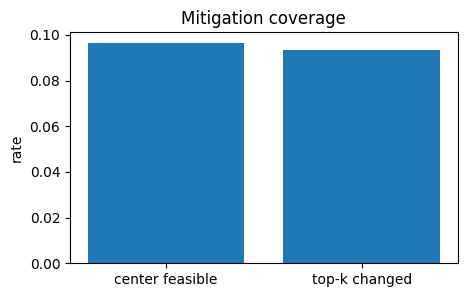

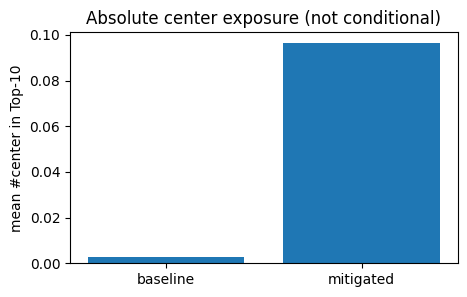

In [12]:
ids = impression_candidates.index[:MAX_IMPRESSIONS]

rows = []
for imp_id in ids:
    cands = impression_candidates.get(imp_id, [])
    if len(cands) == 0:
        continue

    # feasibility: any center in candidates?
    feasible = any(label3(n) == "center" for n in cands)

    # baseline topk
    ranked, _ = baseline_ranked(imp_id, pop_score_fn)
    base_topk = ranked[:K]
    base_center = sum(label3(n) == "center" for n in base_topk)
    base_labeled = sum(label3(n) is not None for n in base_topk)

    # mitigated topk
    mit_topk = ensure_min_center_topk(imp_id, pop_score_fn, k=K, min_center=1)
    mit_center = sum(label3(n) == "center" for n in mit_topk)
    mit_labeled = sum(label3(n) is not None for n in mit_topk)

    changed = set(mit_topk) != set(base_topk)

    rows.append({
        "feasible_center": feasible,
        "changed": changed,
        "base_center_in_topk": base_center,
        "mit_center_in_topk": mit_center,
        "base_labeled_in_topk": base_labeled,
        "mit_labeled_in_topk": mit_labeled,
    })

diag = pd.DataFrame(rows)

# ---- summary ----
summary = pd.Series({
    "p_center_feasible": diag["feasible_center"].mean(),
    "p_topk_changed": diag["changed"].mean(),
    "mean_center_in_topk_baseline": diag["base_center_in_topk"].mean(),
    "mean_center_in_topk_mitigated": diag["mit_center_in_topk"].mean(),
    "mean_labeled_in_topk_baseline": diag["base_labeled_in_topk"].mean(),
    "mean_labeled_in_topk_mitigated": diag["mit_labeled_in_topk"].mean(),
})
display(summary)

# ---- Plot 1: feasibility vs change rate ----
plt.figure(figsize=(5,3))
plt.bar(["center feasible", "top-k changed"], [summary["p_center_feasible"], summary["p_topk_changed"]])
plt.ylabel("rate")
plt.title("Mitigation coverage")
plt.show()

# ---- Plot 2: absolute center count in top-k ----
plt.figure(figsize=(5,3))
plt.bar(["baseline", "mitigated"], [summary["mean_center_in_topk_baseline"], summary["mean_center_in_topk_mitigated"]])
plt.ylabel(f"mean #center in Top-{K}")
plt.title("Absolute center exposure (not conditional)")
plt.show()


### Interpretation

- **Center is rarely available:** `p_center_feasible ≈ 0.096` shows that only ~9.6% of impressions contain any center item in the candidate slate. In the remaining ~90% of impressions, no reranking rule can increase center exposure because there is no supply.
- **The reranker acts almost whenever it can:** `p_topk_changed ≈ 0.094` is very close to `p_center_feasible`, meaning that in almost every feasible impression the Top-10 is modified to include center.
- **Absolute center exposure increases strongly (when feasible):**
  - Baseline: `mean_center_in_topk ≈ 0.0028` (center almost never appears in Top-10).
  - Mitigated: `mean_center_in_topk ≈ 0.096`, which matches the expected effect of enforcing **1 center in Top-10** whenever center exists in candidates.
- **Trade-off:** `mean_labeled_in_topk` increases (~0.218 → ~0.310), indicating that the mitigation injects more labeled political items into Top-10. The ranking-quality metrics (MRR/nDCG) showed only a very small decrease, suggesting the swap is typically “cheap” in relevance terms, but it still changes the content mix.

Overall, this mitigation addresses **ranking suppression** (center disappearing when available), but it cannot solve the dominant limitation: **center scarcity in the candidate pool**.


--------------------------------------------

### Longer-horizon and intervention-style mitigations (beyond *t → t+1*)

Most of the analyses in this project look at **short-term effects** (what happens after a click, or what changes from candidates to Top-K).  
However, exposure imbalance can also be addressed with **multi-step, history-aware policies**, where the system reacts to *patterns over time* rather than to a single interaction.

Examples of longer-horizon mitigation strategies:

- **Exposure balancing over windows:** track each user’s exposure over a recent window (e.g., last `N` impressions / last `T` days).  
  If a user has had **scarce exposure** to a content type (e.g., politics, center), the system can gently increase its probability of appearing *when available*.

- **Saturation control (“too much of X”):** if a user has been repeatedly exposed to one topic/ideology (high concentration), apply a soft penalty or cap to reduce over-dominance and prevent “getting stuck” in a narrow feed.

- **Periodic diversity injections / interruptions:** occasionally introduce recommendations that are **more diverse than the user’s usual feed** (topic/ideology/source diversity).  
  This creates opportunities for interaction with alternative content and helps break self-reinforcing loops.

- **Adaptive constraints instead of fixed ones:** floors/caps can be **conditional** on the user’s recent exposure history and on item availability, rather than always enforcing the same rule.

Overall, these approaches treat bias and underrepresentation as **accumulated exposure dynamics**, not only as “one click causes one immediate consequence”. This is especially relevant when short-term event studies are limited by data scarcity (e.g., few center clicks).


## 08 — Wrap-up: Mitigations and Final Conclusions

This notebook consolidates the key findings from the previous notebooks and tests lightweight mitigation ideas.
The goal is to (1) summarize where exposure bias appears (supply vs ranking effects) and (2) show that simple reranking constraints can reduce harmful exposure patterns with minimal impact on offline ranking utility.


### Recap of findings (Notebooks 04–07)

Across the project we observed two recurring patterns:

1) **Politics exposure imbalance across users**
   - Politically engaged users receive substantially higher political exposure than other users.
   - This indicates a potential *reinforcement loop*: engagement → more political recommendations → more opportunities to keep engaging.

2) **Underrepresentation of “center” inside political content**
   - Center content is **rare in the candidate pool** (supply limitation).
   - Even when center appears in the candidate pool, it can **disappear in Top-K** (ranking suppression).
   - Therefore, not all of the center scarcity is due to supply: part of it is caused by the ranking step.

We validated that DEV impressions come after TRAIN temporally, so interpreting “past behavior → later exposure” is consistent with the dataset timeline.


### Mitigation A — Reduce the ENGAGED vs OTHER politics exposure gap (Top-K reranking)

**Motivation.** If engaged users get disproportionately more politics than others, the system may amplify political consumption for a subset of users while depriving others of exposure opportunities.

**Idea.** Apply a *soft* reranking policy that:
- slightly **caps** the number of political items in Top-K for ENGAGED users, and
- slightly **floors** the number of political items in Top-K for OTHER users *when feasible* (only if enough political candidates exist).

This aims to shrink the exposure gap without dramatically changing the ranking order.


### Results (Mitigation A)

In our run (K=10), the gap between groups decreased substantially:

- Baseline politics share (ENGAGED vs OTHER): **~0.1568 vs ~0.0445**
- After reranking: **~0.1227 vs ~0.0699**
- Gap (ENGAGED − OTHER): **~0.1123 → ~0.0528** (≈ **53% reduction**)

**Interpretation.**
- The mitigation reduces the “politics concentration” for ENGAGED users while giving OTHER users more chances to see politics.
- The floor is applied only when feasible, so we avoid forcing impossible constraints when the slate has too few political candidates.

**Utility impact (offline).**
MRR@K and nDCG@K remain almost unchanged, suggesting the policy changes exposure composition without meaningfully harming ranking quality in this offline evaluation.


### Mitigation B — “Min-center when feasible” to address center suppression

**Motivation.** We observed that center is rare (supply limitation) and also suppressed by ranking when it exists.

**Idea.** When the candidate slate contains at least one center item, enforce:
- **at least 1 center item in Top-K**, by swapping the lowest-scoring non-center item in Top-K with the best available center item outside Top-K.

This mitigation is explicitly **conditional on supply** (it only acts when center exists in candidates).


### Results (Mitigation B)

Key diagnostic rates:
- `p_center_feasible ≈ 0.096`  
  → only ~9.6% of impressions contain any center candidate.
- `p_topk_changed ≈ 0.094`  
  → reranking changes Top-K almost exactly when it is feasible.

Center exposure in Top-K:
- Baseline mean center in Top-10: **~0.0028**
- Mitigated mean center in Top-10: **~0.096**  
  → center exposure increases sharply, but only in the impressions where center exists in the slate.

**Important note (conditional vs absolute).**
Some tables show very high center percentages (e.g., ~31%). That happens because those distributions are computed **within the labeled 3-class subset** (left/center/right) and/or only in impressions where center is feasible.  
It does **not** mean “31% of the whole feed is center” since it is not relative to absolute exposure.


### Utility impact (Mitigation B)

Offline ranking metrics change only slightly:
- ΔMRR@K ≈ -0.00007
- ΔnDCG@K ≈ -0.00021

This suggests the reranker can improve center exposure *when feasible* with negligible measured impact on offline utility.
However, this is not an online A/B test; it only reflects offline clicked-item evaluation.


### Additional center-focused mitigations (not quantitatively tested)

Notebook 07 highlighted two constraints driving center underexposure:

1) **Supply limitation:** center is a small fraction of political items in the candidate slate.  
2) **Ranking suppression:** even when center exists in candidates, it often **fails to appear in Top-K**.

Beyond the mitigations we tested in this project, there are several practical options (roughly ordered from “cheap” to “strong”):

- **Exploration boost for rare classes:** slightly up-weight center items when present (e.g., multiplicative boost, additive prior, or ε-greedy exploration within politics).
- **Within-politics diversity constraint:** enforce at least `m` center items in Top-K *when available*, falling back gracefully when supply is insufficient.
- **Two-stage ranking:** first decide the politics/non-politics mix, then re-rank political candidates with an objective that balances center vs non-center (or left/center/right).
- **Data mitigation:** improve label quality and coverage (Notebook 06), and/or increase the collection of center sources to reduce the structural scarcity.

Because center availability is low, any “hard” constraint must be **conditional on supply** (i.e., never force impossible quotas when the slate has no center items).

**Why we did not test these quantitatively here.**  
In our dataset, center items are too scarce in the candidate pool to support a stable offline comparison: most impressions simply have no center candidates, and the number of center-click trajectories is very small. A meaningful evaluation would require either:
- **higher center availability** in candidates (more center sources/items), or  
- an **experimental setup** that deliberately injects/collects more center content to measure trade-offs reliably.


### Longer-horizon and intervention-style mitigations (beyond *t → t+1*)

Most of the analyses in this project focus on **short-term dynamics** (e.g., candidates vs Top-K, or *t → t+1* after a click).  
However, exposure imbalance is often better treated as an **accumulated, multi-step phenomenon**, where the system reacts to *patterns over time* rather than a single interaction.

### Examples of longer-horizon strategies

- **Exposure balancing over windows:** track each user’s exposure over a recent window (e.g., last `N` impressions / last `T` days).  
  If a user has had **scarce exposure** to a content type (e.g., politics, center), gently increase its chance of appearing *when available*.

- **Saturation control (“too much of X”):** if a user’s exposure is repeatedly concentrated in one topic/ideology/source, apply a soft penalty or cap to reduce over-dominance and prevent “getting stuck” in a narrow feed.

- **Periodic diversity injections / interruptions:** occasionally inject recommendations that are **more diverse than the user’s usual feed** (topic/ideology/source diversity).  
  This creates opportunities for interaction with alternative content and can break self-reinforcing loops.

- **Adaptive constraints instead of fixed ones:** floors/caps should be **conditional** on (i) recent exposure history and (ii) availability in the candidate slate, rather than enforcing the same rule on every impression.

### Why this matters here

Our short-horizon event study is limited by **data scarcity** (e.g., few center-click events), and many impressions simply have **no center candidates**.  
History-aware policies can still be meaningful under these constraints because they target **exposure trajectories**, not just immediate one-step changes.


## Limitations

- **Supply limitation dominates for center.** If center is missing from the candidate pool, reranking cannot create it.
- **Offline evaluation only.** MRR/nDCG are computed from logged clicks and are a proxy; real user satisfaction would require online testing.
- **Label coverage and label noise.** Some analyses use a labeled subset (3-class left/center/right). Conditioning can distort percentages; absolute exposure metrics should be prioritized.
- **Short-horizon event study.** We evaluated t → t+1. Longer horizons (t+2, t+3) are not feasible due to lack of repeated center events.


## Social impact, influence, and what the public should be aware of

Recommender systems do not only “reflect” user preferences - they can **shape what people end up seeing**, and therefore influence what feels *salient, common, and credible*. In a news context, even small shifts in exposure can accumulate into meaningful social effects.

### Why exposure imbalance matters (social impact)

- **Agenda-setting / salience:** what appears more often in the feed tends to feel more important, even if it is not objectively more important.
- **Polarization risk:** when a feed over-exposes highly partisan content (and under-exposes moderating viewpoints), it can reinforce *us-vs-them* framing and reduce perceived legitimacy of alternative positions.
- **Underrepresentation harms:** if “center” or moderate viewpoints are structurally rare or suppressed by ranking, users may get a distorted view of the spectrum of opinions that exist, which can affect civic understanding and dialogue.
- **Information deprivation:** very low political exposure for some users can reduce opportunities for learning about public issues, while very high exposure for others can create saturation or “politics-only” feeds.
- **Feedback loops:** interactions (clicks) can become signals that intensify future recommendations, creating self-reinforcing patterns that are hard to escape without deliberate interventions.

### What the public should be aware of

- **A feed is not “the news”:** it is an *algorithmic selection* optimized for engagement and relevance, not for completeness or balance.
- **Silence ≠ absence:** if you don’t see certain viewpoints/topics, it may be because of **candidate supply limits**, ranking choices, or your interaction history - not because they don’t exist.
- **Engagement signals can backfire:** clicking out of curiosity, outrage, or “doomscrolling” can still train the system to show more of that content.
- **Diversity requires design:** balanced exposure rarely happens automatically; it typically requires explicit constraints, exploration, or long-horizon policies.
- **Transparency helps:** users benefit from clear explanations (e.g., “why am I seeing this?”), controls (topic/ideology tuning), and indicators of uncertainty/coverage.

### Practical responsibility points (for platforms)

- **Measure exposure, not just accuracy:** complement MRR/nDCG with exposure metrics (topic/ideology share, concentration, availability vs ranking effect).
- **Condition constraints on supply:** fairness rules must “fallback gracefully” when content is unavailable (to avoid artificial inflation or brittle behavior).
- **Avoid one-size-fits-all:** mitigate both extremes (over-exposure and deprivation) using history-aware policies (windows, saturation control, periodic injections).
- **Audit continuously:** dataset shifts and label coverage issues can silently break fairness assumptions, so monitoring should be ongoing.

**Bottom line:** recommendation quality is not only about “predicting clicks” - it also shapes public understanding. Users should treat feeds as curated, and platforms should treat exposure dynamics as a first-class objective alongside engagement and accuracy.


## Final conclusions

1) **Exposure bias is multi-stage.**
   - Some imbalance is caused by **candidate availability** (supply), and some by **ranking** (selection into Top-K).

2) **Engagement-linked politics exposure suggests reinforcement risk.**
   - Users who engage with politics are shown substantially more politics, which can sustain a feedback loop.

3) **Center is structurally underrepresented and further suppressed by ranking.**
   - Center appears in candidates rarely, and when available it can still disappear in Top-K.

4) **Simple, conditional reranking mitigations can help.**
   - A soft cap/floor can reduce the ENGAGED vs OTHER gap.
   - A “min-center when feasible” rule can prevent ranking from completely removing center when it exists.
   - Both showed negligible changes in offline MRR/nDCG in our runs.

Overall, the strongest practical takeaway is: **fairness-aware reranking should be conditional on supply and measured using absolute exposure, not only conditional shares.**
